# Taller — Regresion: Prediccion de Precio de Vehiculos
## Dataset: Prediccion de Precio de Automoviles

**Dataset:** `CarPrice_Assignment.csv` — 205 registros, 26 columnas
**Objetivo del negocio:** Predecir el precio de un vehiculo a partir de sus caracteristicas
tecnicas y de diseno (motor, dimensiones, tipo de combustible, marca, etc.), para apoyar
decisiones de fijacion de precios y estudios de mercado.

**Contenido del taller:**
- Parte 1 — Comprension del problema
- Parte 2 — Exploracion de datos (EDA)
- Parte 3 — Preparacion de datos
- Parte 4 — Modelado (2 modelos)
- Parte 5 — Evaluacion del modelo
- Parte 6 — Interpretacion de resultados

---
**Archivo requerido:** `CarPrice_Assignment.csv` en la misma carpeta que este notebook.

## Librerias e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Herramientas de Machine Learning de scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Estilo general para todas las graficas del taller
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.7,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

# pd.read_csv() carga el archivo CSV y lo convierte en un DataFrame de Pandas,
# que es basicamente una tabla con filas y columnas que podemos manipular desde Python.
df = pd.read_csv('CarPrice_Assignment.csv')
print(f"Archivo cargado: {df.shape[0]} filas y {df.shape[1]} columnas")

Archivo cargado: 205 filas y 26 columnas


---
## Parte 1 — Comprension del Problema

Antes de escribir una sola linea de codigo de Machine Learning, hay que entender
bien que es lo que queremos predecir y que tipo de problema es.
Esto determina todo lo que viene despues: que modelos usar, como evaluar
y como interpretar los resultados.


### 1.1 Variable objetivo (target)

In [2]:
# Mostramos estadísticas clave de la variable objetivo para entender su distribución.
# Al ser una variable continua (regresión), analizamos sus medidas estadísticas en lugar de contar clases.

print("Variable objetivo: price")
print("-" * 30)
print(f"Precio Promedio : ${df['price'].mean():,.2f}")
print(f"Precio Mínimo   : ${df['price'].min():,.2f}")
print(f"Precio Máximo   : ${df['price'].max():,.2f}")
print(f"Precio Mediano  : ${df['price'].median():,.2f}")

Variable objetivo: price
------------------------------
Precio Promedio : $13,276.71
Precio Mínimo   : $5,118.00
Precio Máximo   : $45,400.00
Precio Mediano  : $10,295.00


### Respuestas — Comprension del problema

**Cual es la variable objetivo?**
> La variable objetivo es `price`, el precio del vehiculo en dolares. Es una variable numerica continua: puede tomar cualquier valor dentro de un rango (en este dataset, entre $5,118 y $45,400 aproximadamente), no un conjunto fijo de categorias.

**Es un problema de clasificacion o regresion?**
> Es un problema de **regresion**.
> La diferencia entre los dos tipos es la siguiente:
> - Regresion: la variable objetivo es un numero continuo. Por ejemplo, predecir el precio de un carro (puede ser cualquier valor entre $5,000 y $45,000).
> - Clasificacion: la variable objetivo es una categoria discreta. Por ejemplo, si un prestamo se aprueba o se rechaza — solo hay dos opciones posibles.
>
> Por eso es regresion: `price` no tiene un numero fijo de categorias, es un valor numerico que puede variar de forma continua.

**Contexto del problema**
> Un fabricante o distribuidor de automoviles necesita estimar el precio de venta de un vehiculo a partir de sus caracteristicas tecnicas (tamano del motor, peso, potencia, consumo, tipo de carroceria, marca, etc.). Un modelo de Machine Learning puede aprender la relacion entre estas caracteristicas y el precio historico de mercado, y usarla para tasar vehiculos nuevos o comparar la competitividad de precios frente a otras marcas.

---
## Parte 2 — Exploracion de Datos (EDA)

Objetivo: entender la estructura del dataset, detectar problemas de calidad
y conocer la relacion entre las variables antes de limpiar o modelar.


### 2.1 Primeras filas del dataset

In [3]:
# head() muestra las primeras 5 filas.
# En Jupyter el DataFrame se renderiza como tabla automaticamente, sin necesidad de print().
# Aqui podemos ver el formato real de cada columna antes de cualquier transformacion.
df.head()


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


### 2.2 Informacion general del dataset

In [4]:
# info() nos muestra el tipo de dato de cada columna y cuantos valores no nulos hay.
# Las columnas con menos de 614 valores no nulos tienen valores faltantes que hay que manejar.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

### 2.3 Resumen estadistico de variables numericas

In [5]:
# describe() calcula automaticamente estadisticas basicas de las columnas numericas:
# count, media, desviacion estandar, minimo, cuartiles y maximo.
# Aqui podemos detectar outliers — si el maximo esta muy alejado del percentil 75,
# hay valores extremos que pueden afectar el modelo.
df[['enginesize', 'horsepower', 'curbweight', 
    'highwaympg', 'price']].describe().round(1)

,enginesize,horsepower,curbweight,highwaympg,price
count,205.0,205.0,205.0,205.0,205.0
mean,126.9,104.1,2555.6,30.8,13276.7
std,41.6,39.5,520.7,6.9,7988.9
min,61.0,48.0,1488.0,16.0,5118.0
25%,97.0,70.0,2145.0,25.0,7788.0
50%,120.0,95.0,2414.0,30.0,10295.0
75%,141.0,116.0,2935.0,34.0,16503.0
max,326.0,288.0,4066.0,54.0,45400.0


### 2.4 Filas, columnas y duplicados

In [6]:
# shape nos devuelve una tupla (filas, columnas).
print(f"Filas   : {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# duplicated().sum() cuenta cuántas filas son copias exactas de otra fila.
print(f"\nDuplicados exactos: {df.duplicated().sum()}")

# car_ID debería ser único para cada vehículo — lo verificamos.
print(f"car_ID únicos     : {df['car_ID'].nunique()}")


Filas   : 205
Columnas: 26

Duplicados exactos: 0
car_ID únicos     : 205


### 2.5 Valores nulos por columna

In [7]:
# isnull().sum() cuenta cuantos valores vacios (NaN) hay en cada columna.
# Las columnas con nulos necesitan ser tratadas antes de entrenar el modelo,
# porque los algoritmos de Machine Learning no pueden trabajar con valores vacios.
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
resumen_nulos[resumen_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)


,Nulos,Porcentaje (%)


### 2.6 Variables numericas y categoricas

In [8]:
# Separamos las columnas segun su tipo de dato para saber como tratarlas en la preparacion.
# Las categoricas no pueden entrar directamente al modelo — hay que convertirlas a numeros.
cols_numericas   = df.select_dtypes(include=['int64','float64']).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables numericas:")
for c in cols_numericas:
    print(f"  {c}")
print("\nVariables categoricas:")
for c in cols_categoricas:
    print(f"  {c}")


Variables numericas:
  car_ID
  symboling
  wheelbase
  carlength
  carwidth
  carheight
  curbweight
  enginesize
  boreratio
  stroke
  compressionratio
  horsepower
  peakrpm
  citympg
  highwaympg
  price

Variables categoricas:
  CarName
  fueltype
  aspiration
  doornumber
  carbody
  drivewheel
  enginelocation
  enginetype
  cylindernumber
  fuelsystem


### 2.7 Grafica 1 — Distribucion del ingreso segun resultado del prestamo

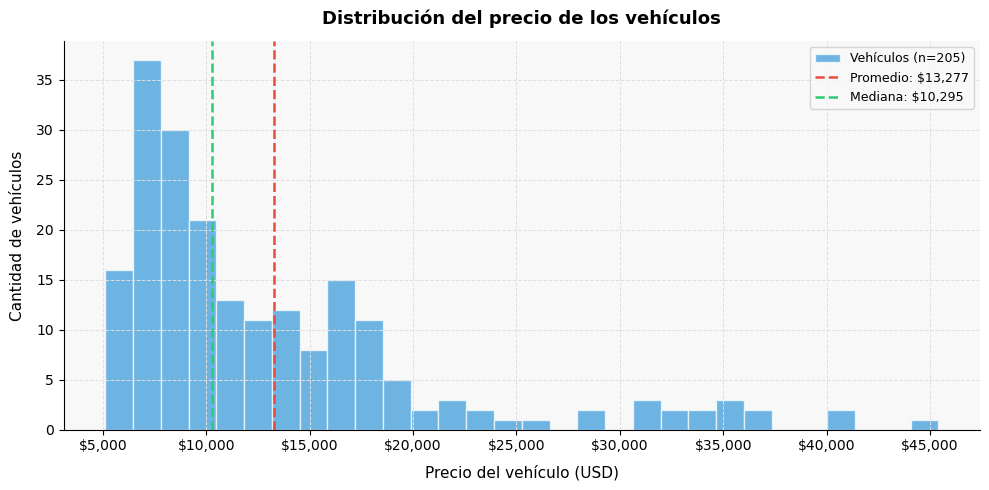

In [9]:
# Esta gráfica nos muestra la distribución de los precios de los vehículos.
# Usamos un histograma y líneas de referencia para la media y la mediana.

fig, ax = plt.subplots(figsize=(10, 5))

precios = df['price']

# Histogram de los precios de los carros
ax.hist(precios, bins=30, color='#3498db', alpha=0.7, edgecolor='white', label=f'Vehículos (n={len(precios)})')

# Líneas verticales para la media y la mediana
ax.axvline(precios.mean(), color='#e74c3c', linestyle='--', linewidth=1.8,
           label=f'Promedio: ${precios.mean():,.0f}')
ax.axvline(precios.median(), color='#2ecc71', linestyle='--', linewidth=1.8,
           label=f'Mediana: ${precios.median():,.0f}')

# Etiquetas y títulos
ax.set_xlabel('Precio del vehículo (USD)', fontsize=11, labelpad=8)
ax.set_ylabel('Cantidad de vehículos', fontsize=11, labelpad=8)
ax.set_title(
    'Distribución del precio de los vehículos',
    fontsize=13, fontweight='bold', pad=12
)

# Formato de dinero en el eje X
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('grafica_1_precio.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

La distribucion del precio esta sesgada hacia la derecha (right-skewed): la mayoria de los vehiculos
se concentra entre $5,000 y $17,000, pero existe una cola de vehiculos de lujo que supera los $30,000
e incluso llega a los $45,400. Por eso el promedio (~$13,277) es mayor que la mediana (~$10,295):
los pocos vehiculos caros "jalan" el promedio hacia arriba.
Este sesgo es importante para el modelado: mas adelante puede ser util aplicar una transformacion
logaritmica a `price` para que los modelos de regresion no le den demasiado peso a los valores extremos.

### 2.8 Grafica 2 — Tasa de aprobacion segun historial crediticio

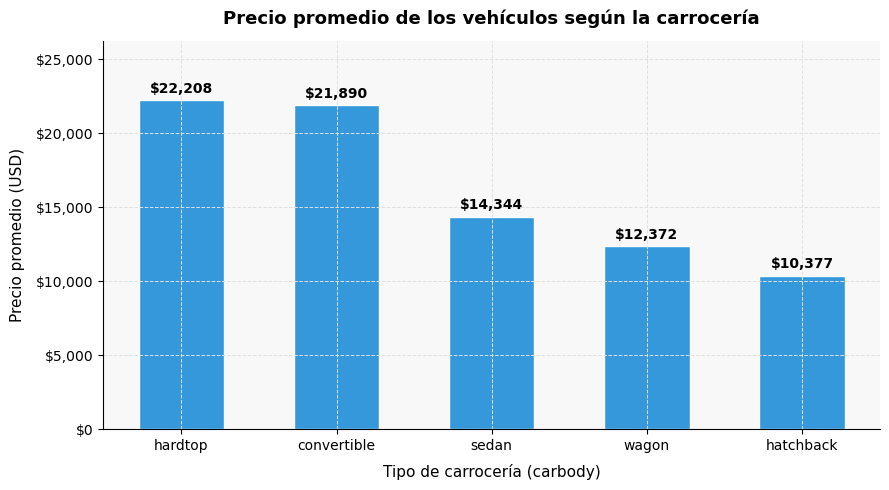

In [10]:
# Analizamos cómo varía el precio promedio según el tipo de carrocería (carbody).
# Agrupamos por 'carbody' y calculamos el precio promedio para cada tipo.

import numpy as np

# Agrupamos y ordenamos los precios de mayor a menor
precio_carroceria = df.groupby('carbody')['price'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

# Graficamos las barras
barras = ax.bar(precio_carroceria.index, precio_carroceria.values, 
                color='#3498db', edgecolor='white', width=0.55)

# Añadimos las etiquetas con los precios sobre cada barra
for b in barras:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 500,
            f'${b.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Tipo de carrocería (carbody)', fontsize=11, labelpad=8)
ax.set_ylabel('Precio promedio (USD)', fontsize=11, labelpad=8)
ax.set_title(
    'Precio promedio de los vehículos según la carrocería',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_ylim(0, precio_carroceria.max() * 1.18)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('grafica_2_carroceria.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

El tipo de carroceria (`carbody`) esta claramente relacionado con el precio promedio.
Los convertibles y hardtops tienden a ser los mas costosos, mientras que hatchbacks y sedanes
se ubican en el rango medio-bajo. Esto tiene sentido desde el punto de vista comercial: los
convertibles suelen ser vehiculos de gama alta o deportivos, mientras que los hatchbacks son
mas comunes en segmentos economicos y familiares.
`carbody` sera, con alta probabilidad, una variable util para el modelo, aunque es de esperar
que variables mecanicas como el tamano del motor o el peso tengan aun mas influencia.

### Respuestas — Exploracion de datos

**Cuantas filas y columnas tiene el dataset?**
> 205 filas y 26 columnas. Cada fila representa un vehiculo diferente.

**Que tipos de datos se identifican?**
> - Numericas: `symboling`, `wheelbase`, `carlength`, `carwidth`, `carheight`, `curbweight`, `enginesize`, `boreratio`, `stroke`, `compressionratio`, `horsepower`, `peakrpm`, `citympg`, `highwaympg`, y la variable objetivo `price`.
> - Categoricas: `CarName`, `fueltype`, `aspiration`, `doornumber`, `carbody`, `drivewheel`, `enginelocation`, `enginetype`, `cylindernumber`, `fuelsystem`.

**Hay columnas con problemas o inconsistencias?**
> No hay valores nulos en ninguna columna (`df.isnull().sum()` da 0 en todas). El unico problema real es `CarName`: tiene 147 valores unicos para solo 205 filas, es decir, casi tan unico como un identificador. Ademas contiene errores de escritura en la marca (por ejemplo `maxda` en vez de `mazda`, `porcshce` en vez de `porsche`, `toyouta` en vez de `toyota`, `vw`/`vokswagen` en vez de `volkswagen`). En la Parte 3 se corrige esto extrayendo solo la marca del vehiculo.

---
## Parte 3 — Preparacion de Datos

Antes de entrenar cualquier modelo hay que dejar los datos en un formato
que los algoritmos de Machine Learning puedan procesar.
Los modelos solo entienden numeros — no texto — y no pueden trabajar con valores vacios.


### 3.1 Crear df1 — copia de trabajo del dataset original

In [11]:
# .copy() crea una copia completamente independiente del DataFrame original.
# Cualquier cambio que hagamos en df1 NO va a afectar a df.
# Esta es una buena práctica: nunca modificar los datos originales.
# También eliminamos car_ID porque es un identificador único que no aporta
# información útil para predecir el precio del vehículo.
df1 = df.drop(columns=['car_ID']).copy()

print(f"Filas en df  (original): {len(df)}")
print(f"Filas en df1 (trabajo) : {len(df1)}")
print(f"\nColumnas de trabajo: {df1.columns.tolist()}")


Filas en df  (original): 205
Filas en df1 (trabajo) : 205

Columnas de trabajo: ['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


### 3.2 Manejo de valores faltantes

In [12]:
# Para columnas categoricas usariamos la moda (el valor mas frecuente).
# Para columnas numericas usariamos la mediana (es robusta ante outliers).
# Aplicamos este proceso de forma generica porque es una buena practica revisarlo
# siempre, aunque en este dataset en particular no hay valores faltantes.

cols_cat = df1.select_dtypes(include=['object']).columns.tolist()
cols_num = df1.select_dtypes(include=['number']).columns.tolist()

huecos_encontrados = False
for col in cols_cat:
    if df1[col].isnull().sum() > 0:
        huecos_encontrados = True
        moda = df1[col].mode()[0]
        df1[col] = df1[col].fillna(moda)
        print(f"  {col:20s} — rellenado con moda     : '{moda}'")

for col in cols_num:
    if df1[col].isnull().sum() > 0:
        huecos_encontrados = True
        mediana = df1[col].median()
        df1[col] = df1[col].fillna(mediana)
        print(f"  {col:20s} — rellenado con mediana  : {mediana:.1f}")

if not huecos_encontrados:
    print("No se encontraron valores nulos en df1 — no fue necesario rellenar nada.")

print(f"\nNulos restantes en df1: {df1.isnull().sum().sum()}")

No se encontraron valores nulos en df1 — no fue necesario rellenar nada.

Nulos restantes en df1: 0


### 3.3 Codificacion de variables categoricas

In [13]:
# CarName tiene 147 valores unicos en 205 filas — es casi tan unico como un ID,
# asi que usarlo tal cual no ayuda al modelo (seria como memorizar cada carro individual).
# En vez de eliminarlo, extraemos solo la marca (la primera palabra), que si se repite
# entre varios vehiculos y puede ser una senal util del precio (ej: 'bmw' vs 'chevrolet').

df1['brand'] = df1['CarName'].str.split().str[0].str.lower()

# Corregimos errores de escritura detectados en la Parte 2 para no duplicar marcas.
correcciones_marca = {
    'maxda': 'mazda',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'vokswagen': 'volkswagen',
    'vw': 'volkswagen',
}
df1['brand'] = df1['brand'].replace(correcciones_marca)

df1 = df1.drop(columns=['CarName'])
print(f"Marcas unicas despues de corregir: {df1['brand'].nunique()}")

# Los modelos de Machine Learning no pueden trabajar con texto como 'gas' o 'sedan'.
# LabelEncoder convierte cada categoria a un numero entero de forma automatica.
# Por ejemplo: fueltype — diesel=0, gas=1

le = LabelEncoder()
cols_a_codificar = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
                    'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']

for col in cols_a_codificar:
    df1[col] = le.fit_transform(df1[col].astype(str))
    print(f"  {col:20s} — valores unicos: {sorted(df1[col].unique())}")

print("\nPrimeras filas de df1 codificado:")
df1.head()

Marcas unicas despues de corregir: 22
  fueltype             — valores unicos: [np.int64(0), np.int64(1)]
  aspiration           — valores unicos: [np.int64(0), np.int64(1)]
  doornumber           — valores unicos: [np.int64(0), np.int64(1)]
  carbody              — valores unicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  drivewheel           — valores unicos: [np.int64(0), np.int64(1), np.int64(2)]
  enginelocation       — valores unicos: [np.int64(0), np.int64(1)]
  enginetype           — valores unicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  cylindernumber       — valores unicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  fuelsystem           — valores unicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  brand                — valores unicos: [np.int64(0), np.int64(1), np.int64(2), np.int64(

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,1,0,1,0,2,0,88.6,168.8,64.1,...,5,3.47,2.68,9.0,111,5000,21,27,13495.0,0
1,3,1,0,1,0,2,0,88.6,168.8,64.1,...,5,3.47,2.68,9.0,111,5000,21,27,16500.0,0
2,1,1,0,1,2,2,0,94.5,171.2,65.5,...,5,2.68,3.47,9.0,154,5000,19,26,16500.0,0
3,2,1,0,0,3,1,0,99.8,176.6,66.2,...,5,3.19,3.40,10.0,102,5500,24,30,13950.0,1
4,2,1,0,0,3,0,0,99.4,176.6,66.4,...,5,3.19,3.40,8.0,115,5500,18,22,17450.0,1


### 3.4 Separacion en X (predictoras) y y (objetivo)

In [14]:
# X contiene todas las columnas que el modelo usara para aprender (variables predictoras).
# y contiene solo la columna que queremos predecir: el precio del vehiculo.
# Los separamos porque los modelos de scikit-learn reciben X e y por separado en .fit().

X = df1.drop(columns=['price'])
y = df1['price']

print(f"X — predictoras: {X.shape[1]} columnas, {X.shape[0]} filas")
print(f"y — objetivo   : {y.shape[0]} valores")
print(f"  Precio minimo  : ${y.min():,.0f}")
print(f"  Precio maximo  : ${y.max():,.0f}")
print(f"  Precio promedio: ${y.mean():,.0f}")
print(f"\nColumnas predictoras:")
print(X.columns.tolist())

X — predictoras: 24 columnas, 205 filas
y — objetivo   : 205 valores
  Precio minimo  : $5,118
  Precio maximo  : $45,400
  Precio promedio: $13,277

Columnas predictoras:
['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'brand']


### 3.5 Division en entrenamiento y prueba (80/20)

In [15]:
# train_test_split divide los datos en dos grupos:
# - Entrenamiento (80%): el modelo aprende con estos datos.
# - Prueba     (20%): evaluamos que tan bien predice el modelo con datos que nunca vio.
#
# A diferencia de un problema de clasificacion, aqui no usamos stratify porque `price`
# es una variable continua, no un conjunto pequeno de categorias que se pueda balancear.
# random_state=42 hace que los resultados sean reproducibles siempre.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Prueba       : {X_test.shape[0]}  filas ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nPrecio promedio en entrenamiento: ${y_train.mean():,.0f}")
print(f"Precio promedio en prueba       : ${y_test.mean():,.0f}")

Entrenamiento: 164 filas (80%)
Prueba       : 41  filas (20%)

Precio promedio en entrenamiento: $13,223
Precio promedio en prueba       : $13,490


### Respuestas — Preparacion de datos

**Como se manejaron los valores faltantes?**
> En este dataset no hubo que manejar valores faltantes: `df1.isnull().sum().sum()` es 0 en todas las columnas. El codigo de relleno con moda/mediana se dejo en el notebook como buena practica general, y aqui confirma que no encontro nada que corregir.

**Por que se usa 80/20 sin stratify?**
> El 80% para entrenamiento le da al modelo suficientes ejemplos para aprender patrones. El 20% de prueba sirve para simular datos nuevos que el modelo nunca vio. No usamos `stratify` porque esa opcion sirve para balancear categorias discretas (por ejemplo, clases en un problema de clasificacion), y aqui `price` es una variable numerica continua. En su lugar, verificamos que el precio promedio en entrenamiento y en prueba sea similar, como una comprobacion informal de que la particion es representativa.

---
## Parte 4 — Modelado

Entrenamos dos modelos distintos para comparar su desempeno.
Ambos son modelos de regresion porque nuestra variable objetivo (`price`) es numerica continua.

- **Modelo 1 — Regresion Lineal:** el modelo mas simple y directo para regresion.
  Ajusta una combinacion lineal de las variables predictoras para estimar el precio.
  Es facil de interpretar y sirve como punto de referencia para comparar otros modelos.

- **Modelo 2 — Random Forest Regressor:** un conjunto de multiples arboles de decision que
  promedian sus predicciones. Suele ser mas preciso porque puede capturar relaciones no
  lineales entre las variables que la regresion lineal no puede detectar.

### 4.1 Modelo 1 — Regresion Lineal

In [16]:
# LinearRegression ajusta una combinacion lineal de las variables predictoras
# que minimiza el error cuadratico entre el precio real y el precio predicho.
# .fit() es el paso de entrenamiento: el modelo ajusta sus coeficientes internos
# para minimizar los errores sobre los datos de entrenamiento.
# .predict() usa el modelo entrenado para predecir el precio del conjunto de prueba.

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

print("Modelo 1 — Regresion Lineal entrenado correctamente.")
print(f"Primeras 5 predicciones  : {[round(p) for p in pred_lr[:5]]}")
print(f"Primeros 5 valores reales: {y_test.values[:5].tolist()}")

Modelo 1 — Regresion Lineal entrenado correctamente.
Primeras 5 predicciones  : [25664, 17886, 9743, 13461, 26417]
Primeros 5 valores reales: [30760.0, 17859.167, 9549.0, 11850.0, 28248.0]


### 4.2 Modelo 2 — Random Forest Regressor

In [17]:
# n_estimators=100 indica que vamos a construir 100 arboles de decision.
# Cada arbol se entrena con una muestra aleatoria de los datos y de las variables,
# y la prediccion final es el promedio de las predicciones de los 100 arboles.
# Este mecanismo de promediado hace al Random Forest mucho mas robusto que un solo arbol.

modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

print("Modelo 2 — Random Forest Regressor entrenado con 100 arboles.")
print(f"Primeras 5 predicciones  : {[round(p) for p in pred_rf[:5]]}")
print(f"Primeros 5 valores reales: {y_test.values[:5].tolist()}")

Modelo 2 — Random Forest Regressor entrenado con 100 arboles.
Primeras 5 predicciones  : [35470, 19320, 9000, 12879, 27730]
Primeros 5 valores reales: [30760.0, 17859.167, 9549.0, 11850.0, 28248.0]


---
## Parte 5 — Evaluacion del Modelo

Como es un problema de regresion, usamos metricas que miden que tan lejos quedan
las predicciones del valor real, no metricas de aciertos/errores por clase.

- **MAE (Error Absoluto Medio):** el promedio de cuanto se equivoca el modelo, en dolares,
  sin importar si predice de mas o de menos. Facil de interpretar directamente en la
  unidad del precio.
- **RMSE (Raiz del Error Cuadratico Medio):** parecido al MAE, pero penaliza mas fuerte
  los errores grandes (porque eleva al cuadrado antes de promediar). Util para detectar
  si el modelo falla mucho en algunos casos puntuales.
- **R² (Coeficiente de determinacion):** que porcentaje de la variacion del precio explica
  el modelo. Va de 0 a 1 (puede ser negativo si el modelo es peor que predecir siempre el
  promedio). Mientras mas cerca de 1, mejor.

### 5.1 Metricas numericas — comparacion de ambos modelos

In [18]:
# Creamos una funcion para calcular todas las metricas de una vez
# y poder aplicarla a ambos modelos con el mismo codigo.

def evaluar(nombre, y_real, y_pred):
    return {
        'Modelo': nombre,
        'MAE':    round(mean_absolute_error(y_real, y_pred), 1),
        'RMSE':   round(mean_squared_error(y_real, y_pred) ** 0.5, 1),
        'R2':     round(r2_score(y_real, y_pred), 4),
    }

resultados = pd.DataFrame([
    evaluar('Regresion Lineal', y_test, pred_lr),
    evaluar('Random Forest',    y_test, pred_rf),
]).set_index('Modelo')

# Para MAE y RMSE, menor es mejor; para R2, mayor es mejor.
resultados.style.highlight_min(subset=['MAE', 'RMSE'], color='#d5f5e3') \
                 .highlight_max(subset=['R2'], color='#d5f5e3') \
                 .format({'MAE': '{:.1f}', 'RMSE': '{:.1f}', 'R2': '{:.4f}'})

,MAE,RMSE,R2
Modelo,,,
Regresion Lineal,2090.5,3487.7,0.8459
Random Forest,1325.3,1872.8,0.9556


### 5.2 Muestra de predicciones vs valores reales

In [19]:
# classification_report no aplica aqui porque no hay clases — en su lugar,
# armamos una tabla comparando el precio real contra lo predicho por cada modelo,
# junto con el error absoluto, para inspeccionar casos concretos.

comparacion = pd.DataFrame({
    'Precio real':         y_test.values,
    'Pred. Reg. Lineal':   pred_lr.round(0),
    'Error Reg. Lineal':   (y_test.values - pred_lr).round(0),
    'Pred. Random Forest': pred_rf.round(0),
    'Error Random Forest': (y_test.values - pred_rf).round(0),
}).reset_index(drop=True)

comparacion.head(10)

,Precio real,Pred. Reg. Lineal,Error Reg. Lineal,Pred. Random Forest,Error Random Forest
0,30760.000,25664.0,5096.0,35470.0,-4710.0
1,17859.167,17886.0,-26.0,19320.0,-1461.0
2,9549.000,9743.0,-194.0,9000.0,549.0
3,11850.000,13461.0,-1611.0,12879.0,-1029.0
4,28248.000,26417.0,1831.0,27730.0,518.0
5,7799.000,6367.0,1432.0,6541.0,1258.0
6,7788.000,8203.0,-415.0,7897.0,-109.0
7,9258.000,5835.0,3423.0,8062.0,1196.0
8,10198.000,9514.0,684.0,9607.0,591.0
9,7775.000,6923.0,852.0,8167.0,-392.0


### 5.3 Grafica 3 — Valores reales vs valores predichos

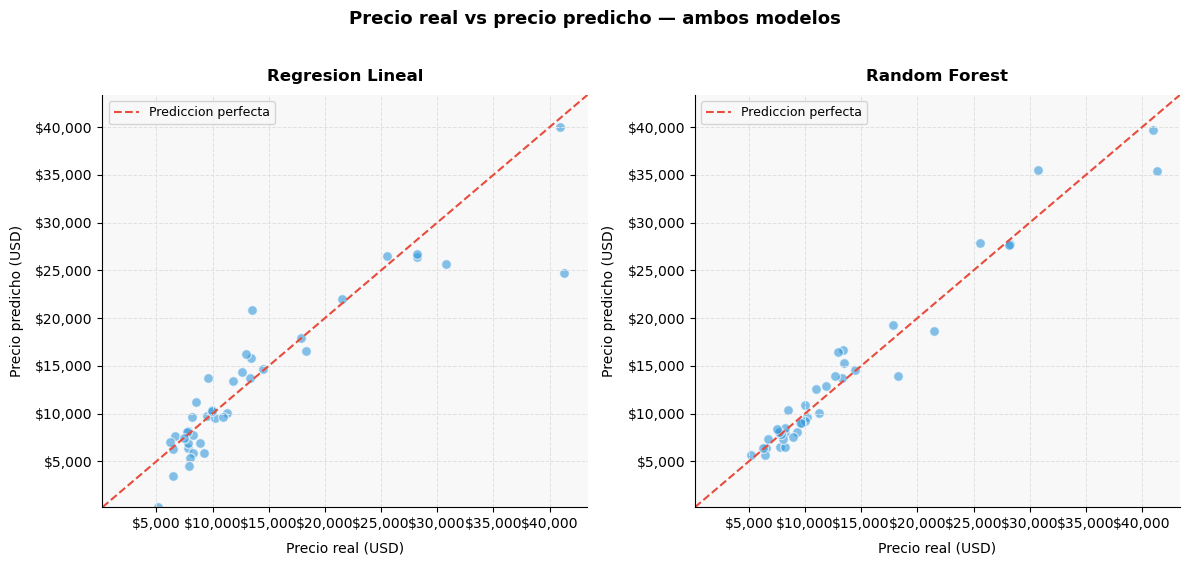

In [20]:
# En regresion, el equivalente visual a una matriz de confusion es un grafico de
# dispersion entre el valor real y el valor predicho. Si el modelo fuera perfecto,
# todos los puntos caerian exactamente sobre la linea diagonal (real = prediccion).

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
modelos = [('Regresion Lineal', pred_lr), ('Random Forest', pred_rf)]

lim_min = min(y_test.min(), pred_lr.min(), pred_rf.min()) * 0.95
lim_max = max(y_test.max(), pred_lr.max(), pred_rf.max()) * 1.05

for ax, (nombre, pred) in zip(axes, modelos):
    ax.scatter(y_test, pred, alpha=0.6, color='#3498db', edgecolor='white', s=50)
    ax.plot([lim_min, lim_max], [lim_min, lim_max], color='#e74c3c', linestyle='--',
            linewidth=1.5, label='Prediccion perfecta')

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)
    ax.set_xlabel('Precio real (USD)', fontsize=10, labelpad=8)
    ax.set_ylabel('Precio predicho (USD)', fontsize=10, labelpad=8)
    ax.set_title(nombre, fontsize=12, fontweight='bold', pad=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=9)

plt.suptitle('Precio real vs precio predicho — ambos modelos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('grafica_3_real_vs_predicho.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretacion**

En ambos modelos los puntos se agrupan cerca de la linea diagonal, lo que indica que las
predicciones siguen razonablemente bien al precio real. La Regresion Lineal muestra mas
dispersion, especialmente en los vehiculos mas caros (por encima de $25,000), donde tiende
a subestimar el precio. El Random Forest se ajusta mas de cerca a la diagonal en todo el
rango de precios, lo que es consistente con que puede capturar relaciones no lineales entre
las caracteristicas del carro y su precio (por ejemplo, que el efecto del tamano del motor
sobre el precio no es igual de fuerte en carros economicos que en carros de lujo).

### 5.4 Grafica 4 — Importancia de variables (Random Forest)

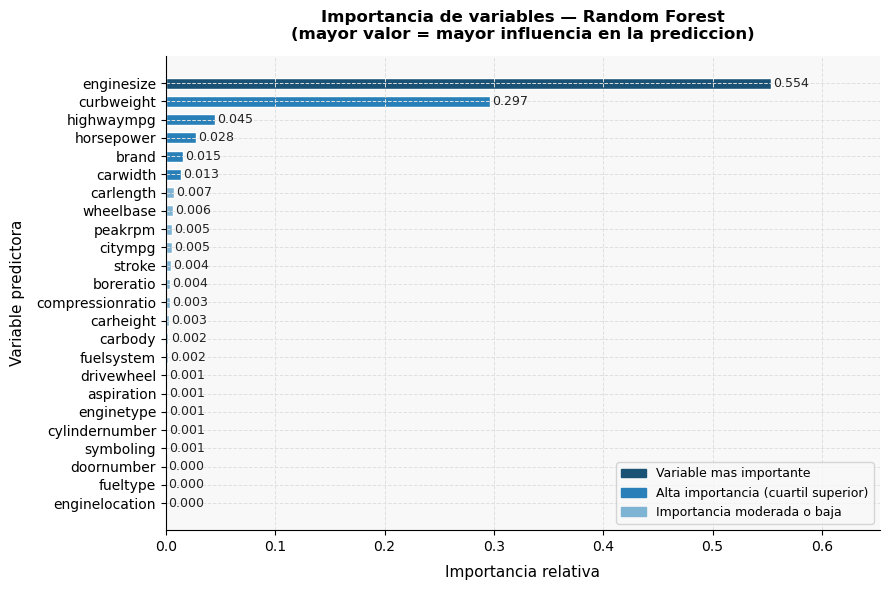

In [21]:
# Random Forest puede calcular la importancia de cada variable predictora.
# Una variable es importante si usarla para dividir los datos reduce mucho
# el error de prediccion en promedio a lo largo de todos los 100 arboles.
# Esto nos permite entender que variables son las que mas influyen en la decision del modelo.

importancias = pd.Series(
    modelo_rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

colores = ['#1a5276' if v == importancias.max() else
           '#2980b9' if v >= importancias.quantile(0.75) else
           '#7fb3d3' for v in importancias.values]

barras = ax.barh(importancias.index, importancias.values,
                 color=colores, edgecolor='white', height=0.6)

for b in barras:
    ax.text(b.get_width() + 0.002,
            b.get_y() + b.get_height() / 2,
            f'{b.get_width():.3f}',
            va='center', fontsize=9, color='#222222')

ax.set_xlabel('Importancia relativa', fontsize=11, labelpad=8)
ax.set_ylabel('Variable predictora', fontsize=11, labelpad=8)
ax.set_title(
    'Importancia de variables — Random Forest\n(mayor valor = mayor influencia en la prediccion)',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlim(0, importancias.max() * 1.18)

from matplotlib.patches import Patch
leyenda = [
    Patch(color='#1a5276', label='Variable mas importante'),
    Patch(color='#2980b9', label='Alta importancia (cuartil superior)'),
    Patch(color='#7fb3d3', label='Importancia moderada o baja'),
]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('grafica_4_importancia.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretacion**

`enginesize` (tamano del motor) es, por un margen amplio, la variable mas importante del
modelo, seguida de `curbweight` (peso del vehiculo en vacio). Entre las dos explican mas
del 80% de la importancia total. Esto tiene sentido mecanico y comercial: motores mas
grandes suelen ser mas potentes y costosos de fabricar, y los vehiculos mas pesados suelen
ser de gama alta o de mayor tamano. `highwaympg` y `horsepower` aparecen en un distante
tercer y cuarto lugar. Variables mas cosmeticas, como el tipo de carroceria o el numero de
puertas, tienen una influencia mucho menor en comparacion con las caracteristicas del motor
y el peso.

---
## Parte 6 — Interpretacion de Resultados

Esta parte responde las tres preguntas clave de interpretacion del taller,
basandose en los resultados numericos y graficos de las partes anteriores.


### 6.1 Que tan bueno es el modelo?

In [22]:
# Recuperamos las metricas de ambos modelos para analizar su desempeno en detalle.
# Un modelo "bueno" en regresion no solo tiene R2 alto — tambien debe tener errores
# (MAE, RMSE) que sean aceptables en la escala real del negocio (dolares, en este caso).

print("Resumen de metricas — ambos modelos")
print("=" * 52)
for nombre, pred in [('Regresion Lineal', pred_lr), ('Random Forest', pred_rf)]:
    mae  = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2   = r2_score(y_test, pred)
    print(f"\n{nombre}")
    print(f"  MAE : ${mae:,.0f}  — en promedio, la prediccion se equivoca por esa cantidad")
    print(f"  RMSE: ${rmse:,.0f}  — penaliza mas los errores grandes")
    print(f"  R2  : {r2:.2%}  — el modelo explica el {r2*100:.0f}% de la variacion del precio")

Resumen de metricas — ambos modelos

Regresion Lineal
  MAE : $2,091  — en promedio, la prediccion se equivoca por esa cantidad
  RMSE: $3,488  — penaliza mas los errores grandes
  R2  : 84.59%  — el modelo explica el 85% de la variacion del precio

Random Forest
  MAE : $1,325  — en promedio, la prediccion se equivoca por esa cantidad
  RMSE: $1,873  — penaliza mas los errores grandes
  R2  : 95.56%  — el modelo explica el 96% de la variacion del precio


**Respuesta — Que tan bueno es el modelo?**

El Random Forest alcanza un R² de aproximadamente 0.96, lo que significa que explica cerca
del 96% de la variacion del precio de los vehiculos. Su MAE es de aproximadamente $1,325 —
es decir, en promedio la prediccion se aleja del precio real en esa cantidad, lo cual es un
error razonable si se compara con el precio promedio del dataset (~$13,277).

La Regresion Lineal tambien tiene un desempeno solido (R² ≈ 0.85), pero su error es notablemente
mayor: MAE de aproximadamente $2,090 y RMSE de aproximadamente $3,488, casi el doble que el
Random Forest. Esto sugiere que la relacion entre las caracteristicas del carro y su precio
no es completamente lineal — hay interacciones (por ejemplo, entre tamano de motor y marca)
que el Random Forest puede capturar y la Regresion Lineal no.

Comparando ambos modelos, el Random Forest supera claramente a la Regresion Lineal en las
tres metricas, por lo que es el modelo recomendado de los dos.

### 6.2 Que variable parece influir mas en la prediccion?

In [23]:
# Mostramos las importancias ordenadas de mayor a menor para tener una lectura clara.
importancias_df = pd.Series(
    modelo_rf.feature_importances_, index=X.columns
).sort_values(ascending=False).reset_index()
importancias_df.columns = ['Variable', 'Importancia']
importancias_df['Importancia (%)'] = (importancias_df['Importancia'] * 100).round(1)
importancias_df


,Variable,Importancia,Importancia (%)
0,enginesize,0.553578,55.4
1,curbweight,0.296789,29.7
2,highwaympg,0.045180,4.5
3,horsepower,0.027618,2.8
4,brand,0.015461,1.5
5,carwidth,0.013467,1.3
6,carlength,0.007216,0.7
7,wheelbase,0.006288,0.6
8,peakrpm,0.005209,0.5
9,citympg,0.005120,0.5


**Respuesta — Que variable influye mas?**

`enginesize` (tamano del motor) es, con diferencia, la variable mas influyente del modelo,
explicando alrededor del 55% de la importancia total del Random Forest. En segundo lugar
aparece `curbweight` (peso del vehiculo), con cerca del 30%. Entre ambas concentran mas del
80% de la capacidad predictiva del modelo.

Esto es coherente con la logica del mercado automotriz: motores mas grandes suelen ser mas
potentes, mas costosos de fabricar y se instalan en vehiculos de gama alta, mientras que el
peso del vehiculo refleja su tamano general y los materiales usados, que tambien elevan el
costo. `highwaympg` y `horsepower` aparecen en tercer y cuarto lugar, con una influencia
mucho menor: tiene sentido, porque su efecto sobre el precio esta parcialmente correlacionado
con el tamano del motor (motores mas grandes suelen consumir mas y rendir menos millas por
galon).

Variables mas relacionadas con el diseno o la carroceria, como `carbody` o `doornumber`,
tienen una influencia comparativamente baja: el precio de un vehiculo esta determinado
principalmente por su mecanica, no por su forma exterior.

### 6.3 Que mejorarias si tuvieras mas tiempo?

**Respuesta — Que mejorarias?**

Hay varias areas donde el modelo podria mejorar con mas tiempo y recursos:

**1. Transformacion del precio (log-transform)**
`price` esta sesgado hacia la derecha (algunos vehiculos de lujo superan los $40,000).
Entrenar los modelos sobre `log(price)` en vez de `price` directamente suele ayudar a que
el modelo no se enfoque demasiado en los pocos casos caros y mejore el error en el resto del
rango de precios.

**2. Ajuste de hiperparametros (GridSearchCV o RandomizedSearchCV)**
El Random Forest que entrenamos usa los parametros por defecto de scikit-learn. Con una
busqueda sistematica de `n_estimators`, `max_depth`, `min_samples_split` y otros parametros
podriamos reducir aun mas el MAE y el RMSE.

**3. Revisar multicolinealidad**
Variables como `enginesize`, `curbweight`, `horsepower` y `carwidth` estan probablemente
correlacionadas entre si (los carros grandes tienden a tener motores grandes y ser mas
pesados). Esto no afecta mucho al Random Forest, pero si puede distorsionar los coeficientes
de la Regresion Lineal. Revisar la correlacion entre predictoras, o usar Ridge/Lasso en vez
de una regresion lineal simple, podria mejorar su estabilidad.

**4. Ingenieria de variables (feature engineering)**
Podriamos crear variables derivadas de las existentes, por ejemplo:
- `potencia_por_peso` = horsepower / curbweight
- `tamano_promedio` = (carlength + carwidth + carheight) / 3
- Usar `brand` con una codificacion mas informativa que LabelEncoder (por ejemplo, precio
  promedio historico de la marca), ya que LabelEncoder le asigna un numero arbitrario que no
  refleja que unas marcas son mas premium que otras.

**5. Probar otros modelos y validacion cruzada**
Con mas tiempo probaria Gradient Boosting o XGBoost, que suelen superar al Random Forest base
en datasets pequenos y estructurados como este. Tambien usaria k-fold cross validation en
vez de una sola division 80/20, para que la evaluacion sea mas robusta dado que el dataset
solo tiene 205 filas.

---
## Conclusiones del Taller

**Tipo de problema**
La prediccion del precio de un vehiculo es un problema de regresion. La variable objetivo
`price` es un numero continuo, por lo que los modelos de clasificacion no aplican en este
caso.

**Variable mas importante**
`enginesize` (tamano del motor) domina la prediccion, seguido de `curbweight` (peso del
vehiculo). Juntas explican mas del 80% de la importancia del Random Forest, lo cual es
coherente con la logica del mercado automotriz: motores mas grandes y vehiculos mas pesados
tienden a ser mas costosos.

**Modelo recomendado**
El Random Forest supera a la Regresion Lineal en las tres metricas evaluadas (MAE, RMSE y R²).
Sin embargo, la Regresion Lineal sigue siendo util cuando se necesita explicar la decision
del modelo de forma simple (por ejemplo, "cada centimetro cubico adicional de motor suma X
dolares al precio"), algo que sus coeficientes permiten y que el Random Forest no ofrece de
forma directa.

**Consideracion final**
El precio esta sesgado hacia la derecha por unos pocos vehiculos de lujo. Un siguiente paso
razonable seria entrenar los modelos sobre el logaritmo del precio y evaluar si eso reduce
el error relativo en los vehiculos economicos, que son la mayoria del dataset.